# Imports

In [1]:
import os
import pickle
import sys
from asyncore import compact_traceback
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

# Import project modules
from src.datagen import mackey_glass, generate_narma_data
from src.datagen import split_and_scale_series, split_time_series, fit_minmax_scaler, transform_with_minmax_scaler
from src.models import draw_circuit, gqnn_shape
from projects.trainability_effective_dim.core.model.models import GQNN
from projects.trainability_effective_dim.core.trainers.hyperparameter_trainer import HyperparameterTrainer
from projects.trainability_effective_dim.core.trainers.basic_trainer import BasicTrainer
from projects.expr_train_theory.qfim.core import compute_pure_state_qfim, diagnose_qfim
from projects.trainability_effective_dim.core.model.models import GQNN
from projects.trainability_effective_dim.tests.led_depth_sweep import (
    sweep_led_by_depth,
    plot_led_depth_sweep,
    is_non_decreasing_with_tolerance,
)
from projects.trainability_effective_dim.tests.ged_depth_sweep import (
    is_non_decreasing_with_tolerance,
    plot_ged_depth_sweep,
    sweep_ged_by_depth,
)
from projects.trainability_effective_dim.tests.utility import *
from utils.Charts import multi_plot_flat_ts

from pennylane import numpy as np
import torch
from torch import nn
import pennylane as qml
from torch.utils.data import TensorDataset
import optuna

%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -optuna

### Constants
SEED = 2025
FIGURES_DIR = Path("results")  # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = "default.qubit"  # 'default.qubit' #
interface = "torch"  # 'torch' #
diff_method = (
    "adjoint"  # as we use QRC and no training # 'adjoint' # 'parameter-shift' #
)
level = "gradient"
shots = None

dtype = torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nThe optimum devices: {sim} and {torch_device}")

/tmp/ipykernel_29649/1401104809.py:4: DeprecationWarning: The asyncore module is deprecated and will be removed in Python 3.12. The recommended replacement is asyncio
  from asyncore import compact_traceback


Project root: /home/adrian/Coding-projects/qtsa_expressivity

The optimum devices: default.qubit and cpu


## Models

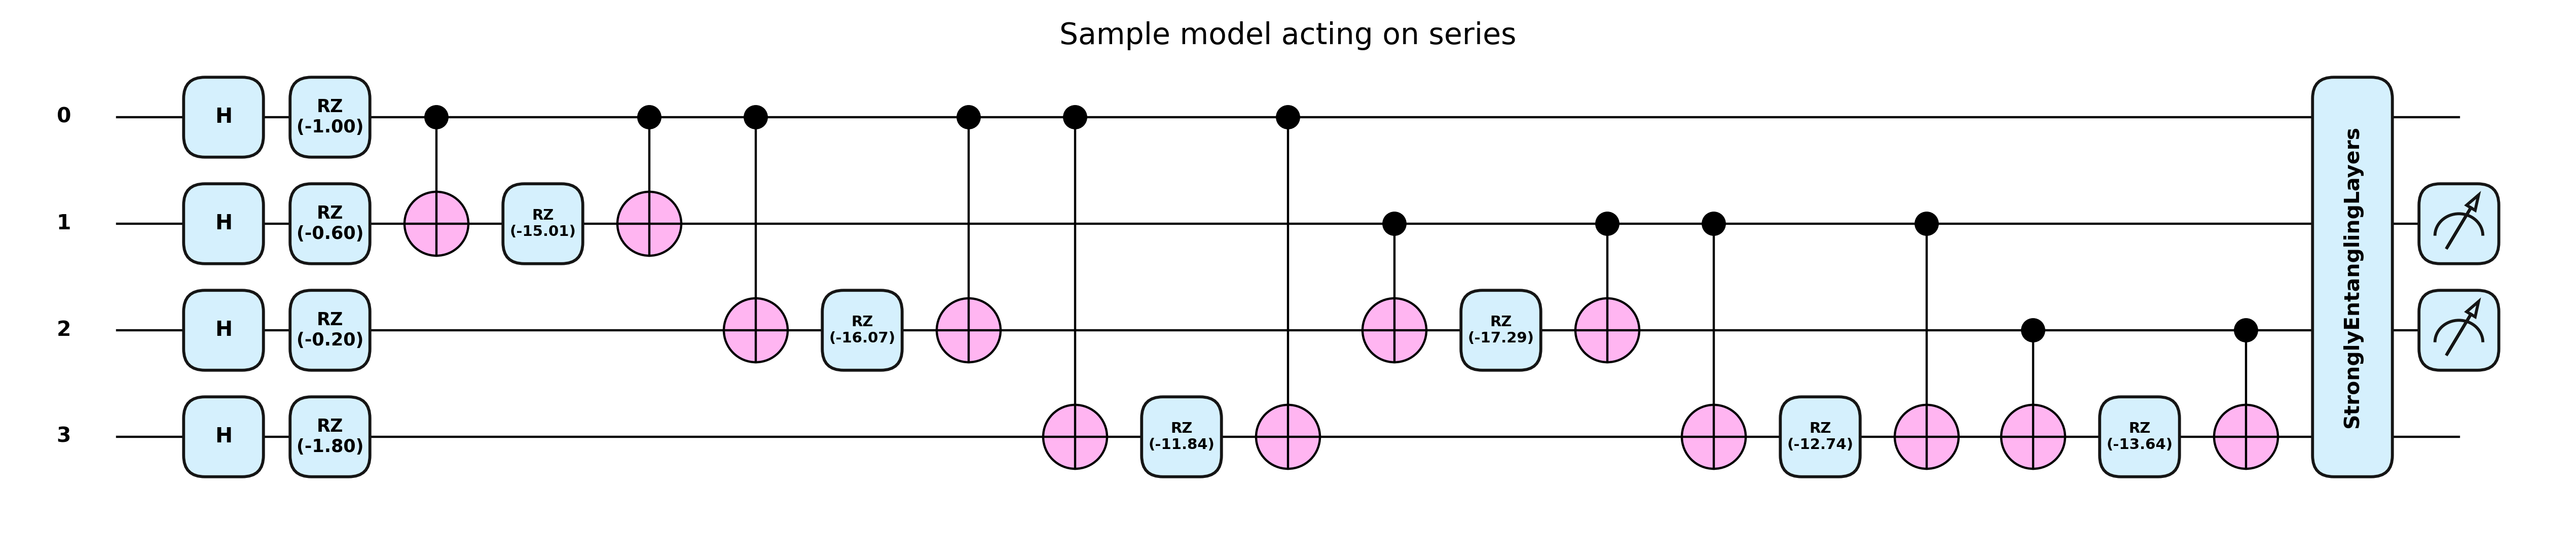

In [19]:
t_n_qubits = 4
t_n_layers = 2
t_inputs = [0.5, 0.3, 0.1, 0.9]
t_shape = gqnn_shape(t_n_layers, t_n_qubits)

t_inputs = torch.tensor(t_inputs, dtype=torch.float64)

dev = qml.device(sim, wires=t_n_qubits)
circuit = GQNN(
    t_n_layers,
    t_n_qubits,
    dev,
    interface=interface,
    diff_method=diff_method,
    fm_style="zzfm",
    meas=[1, 2],
)


circuit.draw_circuit(
    scale=0.7,
    title="Sample model acting on series",
    level="user",
)(
    t_inputs,
    circuit.qlayers.weights,
)

## Datasets

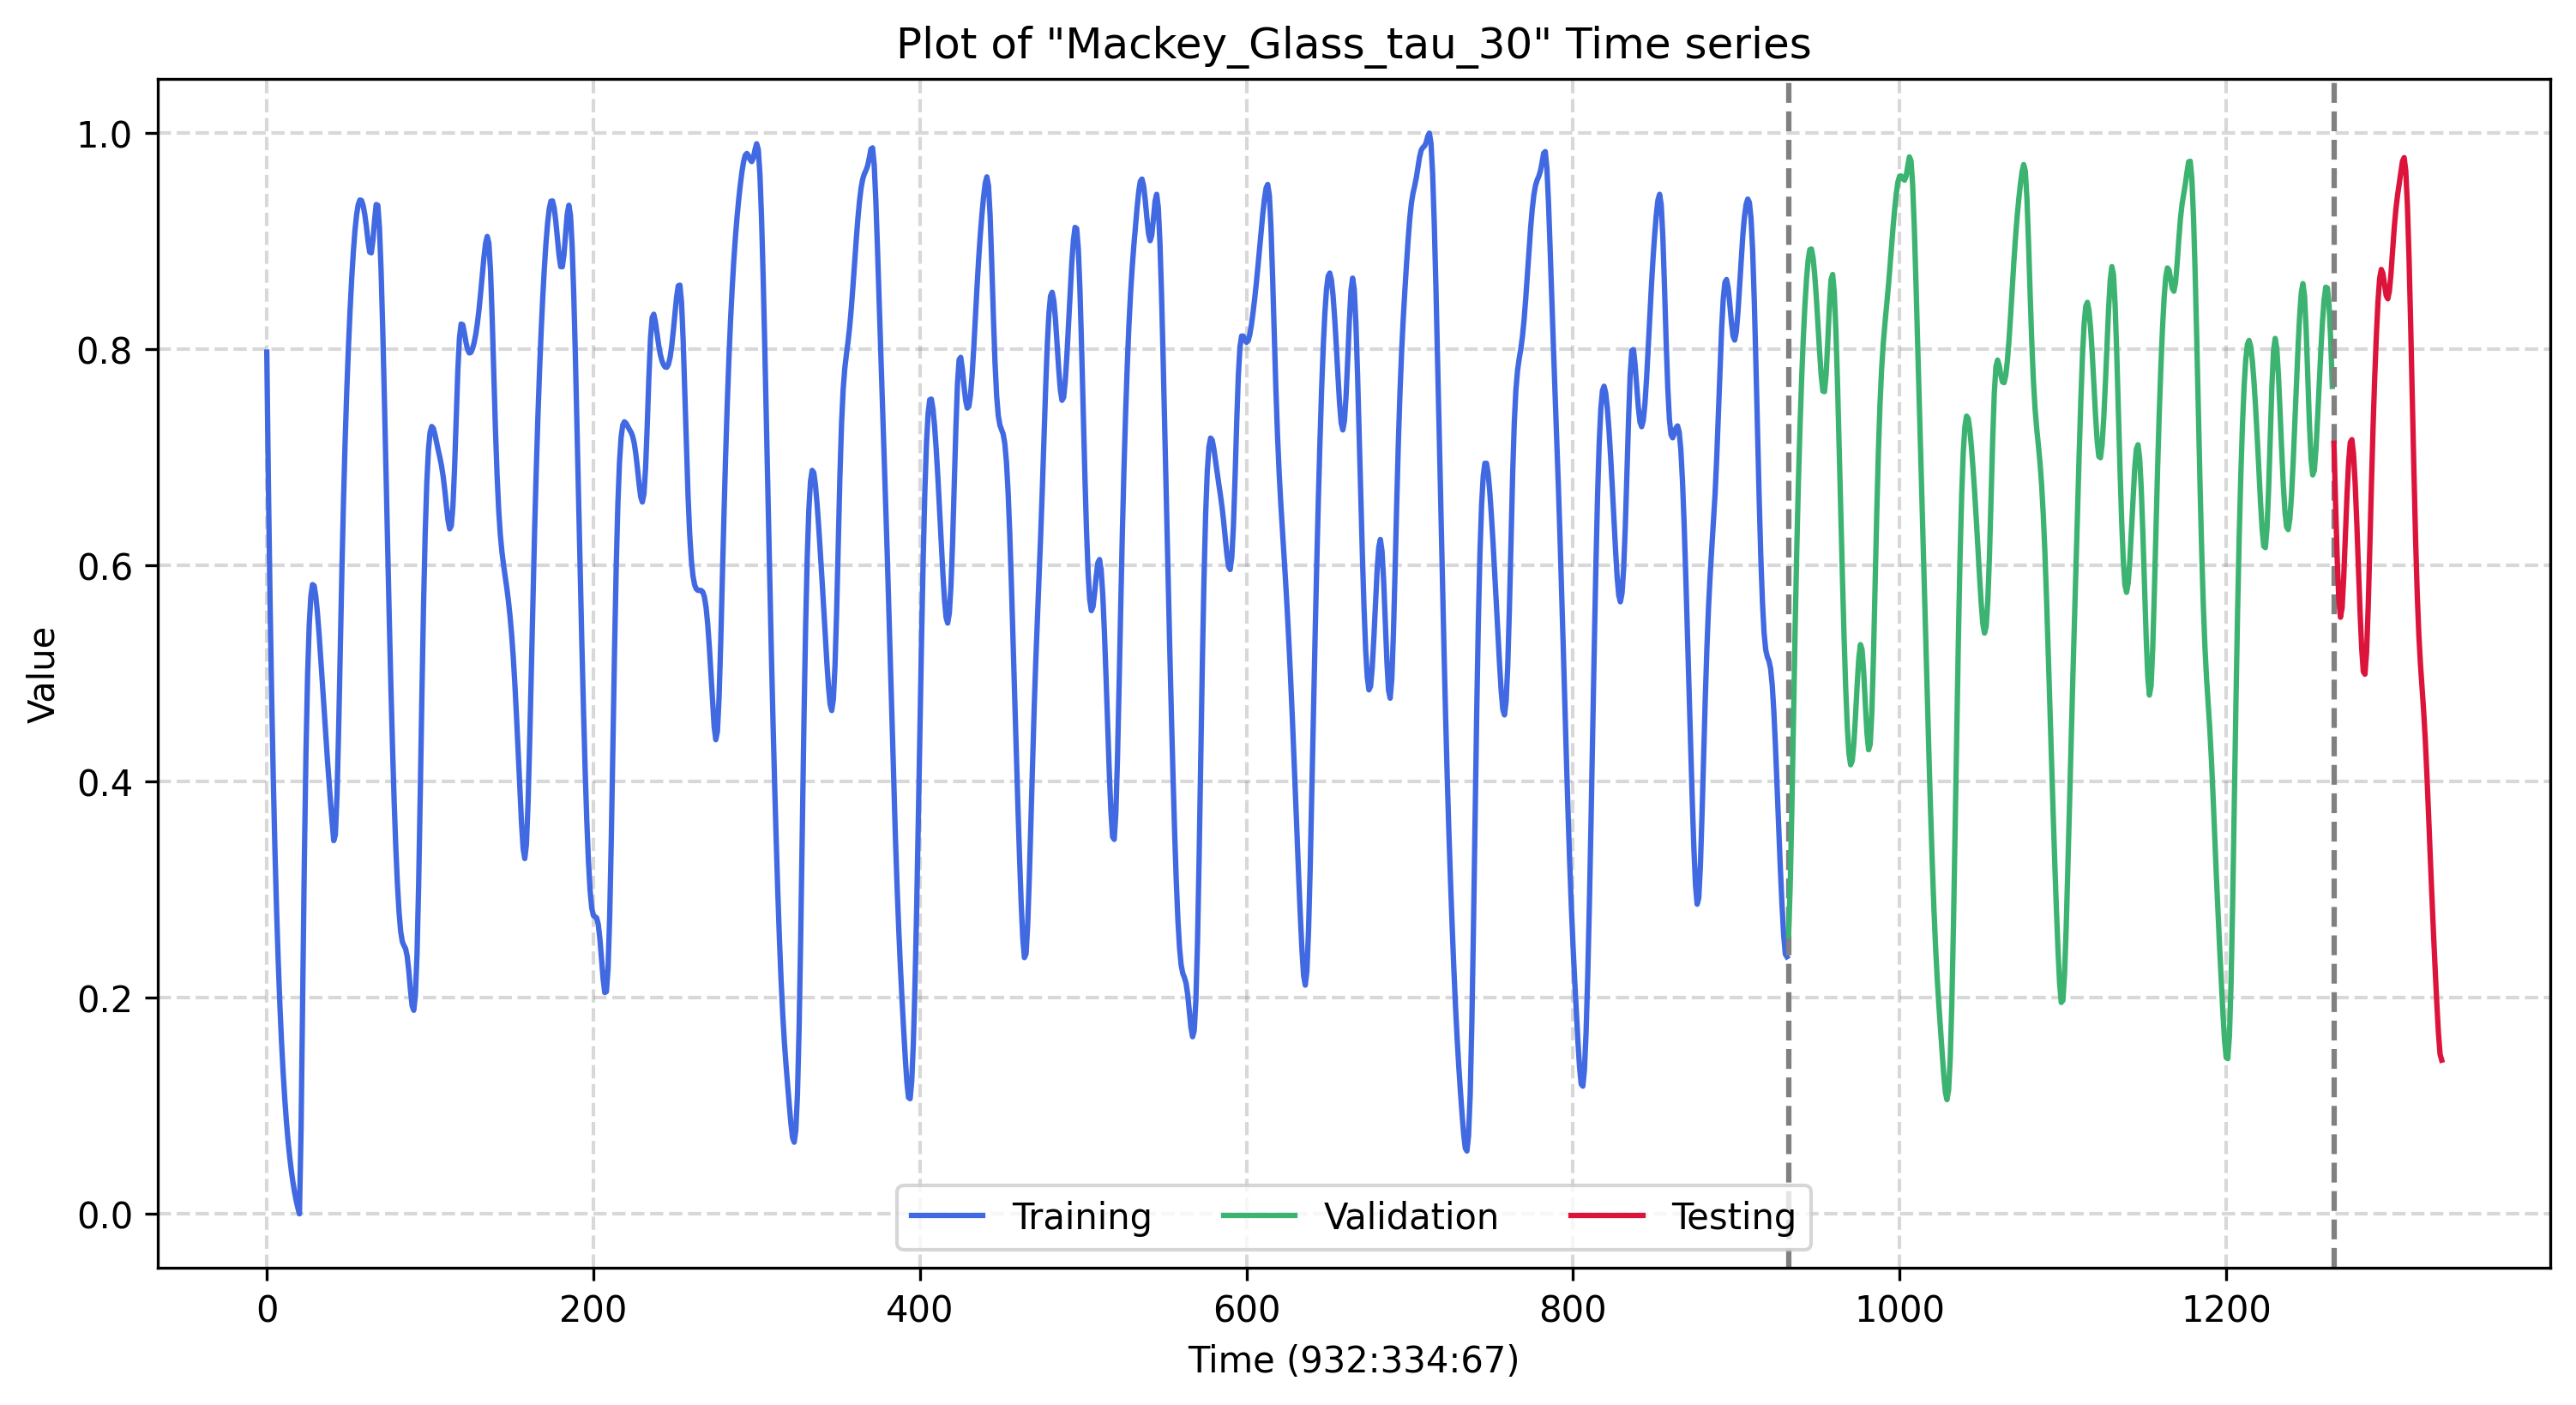

In [17]:
# Set split fractions
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.25
TEST_FRACTION = 1.0 - TRAIN_FRACTION - VAL_FRACTION

if TEST_FRACTION <= 0:
    raise ValueError("TRAIN_FRACTION + VAL_FRACTION must be less than 1.")

### Generate and plot the Mackey-Glass time series
time_series_mg30 = mackey_glass(tau=30)
chart_name_mg30 = "Mackey_Glass_tau_30"

mg30_train_val_raw, mg30_test_raw = split_time_series(
    time_series_mg30,
    train_fraction=TRAIN_FRACTION + VAL_FRACTION,
)

mg30_relative_train_fraction = (
    TRAIN_FRACTION / (TRAIN_FRACTION + VAL_FRACTION)
)

mg30_train_raw, mg30_val_raw = split_time_series(
    mg30_train_val_raw,
    train_fraction=mg30_relative_train_fraction,
)

mg30_scaler = fit_minmax_scaler(mg30_train_raw)

mg30_train = transform_with_minmax_scaler(mg30_train_raw, mg30_scaler)
mg30_val = transform_with_minmax_scaler(mg30_val_raw, mg30_scaler)
mg30_test = transform_with_minmax_scaler(mg30_test_raw, mg30_scaler)

mg30_train_size = len(mg30_train)
mg30_val_size = len(mg30_val)
mg30_test_size = len(mg30_test)

mg30_x_train = list(range(mg30_train_size))
mg30_x_val = list(range(
    mg30_train_size,
    mg30_train_size + mg30_val_size,
))
mg30_x_test = list(range(
    mg30_train_size + mg30_val_size,
    mg30_train_size + mg30_val_size + mg30_test_size,
))

plt.rcParams.update(
    {
        "axes.grid": True,
        "grid.color": "gray",
        "grid.linewidth": 1,
        "grid.alpha": 0.3,
        "axes.axisbelow": True,

    }
)

multi_plot_flat_ts(
    [mg30_x_train, mg30_x_val, mg30_x_test],
    [mg30_train, mg30_val, mg30_test],
    dpi=300,
    rcParams=(12, 6),
    vert_lines=["", "dashed", "dashed"],
    vert_line_color="gray",
    colors=["royalblue", "mediumseagreen", "crimson"],
    lines=["solid", "solid", "solid"],
    xlabel=(
        f"Time "
        f"({mg30_train_size}:{mg30_val_size}:{mg30_test_size})"
    ),
    ylabel="Value",
    labels=["Training", "Validation", "Testing"],
    title=f'Plot of "{chart_name_mg30}" Time series',
    save_plot=FIGURES_DIR / f"xfig_series_{chart_name_mg30}.pdf",
)

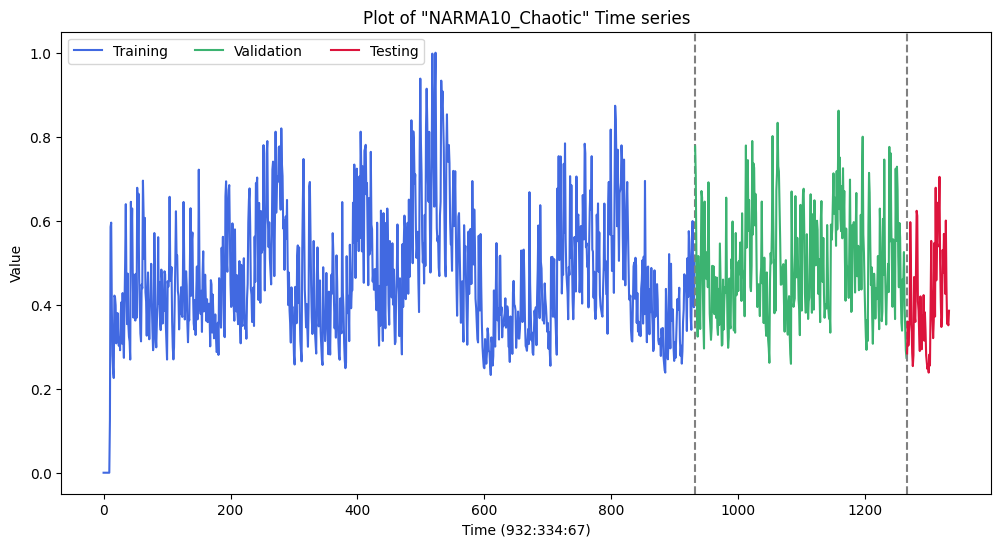

In [4]:
# Set split fractions
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.25
TEST_FRACTION = 1.0 - TRAIN_FRACTION - VAL_FRACTION

if TEST_FRACTION <= 0:
    raise ValueError("TRAIN_FRACTION + VAL_FRACTION must be less than 1.")

### Generate and plot the NARMA10 time series
time_series_narma10 = generate_narma_data(order=10)
chart_name_narma10 = "NARMA10_Chaotic"

narma10_train_val_raw, narma10_test_raw = split_time_series(
    time_series_narma10,
    train_fraction=TRAIN_FRACTION + VAL_FRACTION,
)

narma10_relative_train_fraction = (
    TRAIN_FRACTION / (TRAIN_FRACTION + VAL_FRACTION)
)

narma10_train_raw, narma10_val_raw = split_time_series(
    narma10_train_val_raw,
    train_fraction=narma10_relative_train_fraction,
)

narma10_scaler = fit_minmax_scaler(narma10_train_raw)

narma10_train = transform_with_minmax_scaler(
    narma10_train_raw,
    narma10_scaler,
)
narma10_val = transform_with_minmax_scaler(
    narma10_val_raw,
    narma10_scaler,
)
narma10_test = transform_with_minmax_scaler(
    narma10_test_raw,
    narma10_scaler,
)

narma10_train_size = len(narma10_train)
narma10_val_size = len(narma10_val)
narma10_test_size = len(narma10_test)

narma10_x_train = list(range(narma10_train_size))
narma10_x_val = list(range(
    narma10_train_size,
    narma10_train_size + narma10_val_size,
))
narma10_x_test = list(range(
    narma10_train_size + narma10_val_size,
    narma10_train_size + narma10_val_size + narma10_test_size,
))

multi_plot_flat_ts(
    [narma10_x_train, narma10_x_val, narma10_x_test],
    [narma10_train, narma10_val, narma10_test],
    dpi=100,
    rcParams=(12, 6),
    vert_lines=["", "dashed", "dashed"],
    vert_line_color="gray",
    colors=["royalblue", "mediumseagreen", "crimson"],
    lines=["solid", "solid", "solid"],
    xlabel=(
        f"Time "
        f"({narma10_train_size}:{narma10_val_size}:{narma10_test_size})"
    ),
    ylabel="Value",
    labels=["Training", "Validation", "Testing"],
    title=f'Plot of "{chart_name_narma10}" Time series',
    save_plot=FIGURES_DIR / f"xfig_series_{chart_name_narma10}.png",
)

In [5]:
def create_io_pairs(data, window_size):
    """
    Create one-step-ahead input-output pairs from a time-series segment.

    Args:
        data: One-dimensional scaled time series.
        window_size: Number of past values used as one input sample.

    Returns:
        inputs: Array with shape (n_samples, window_size).
        outputs: Array with shape (n_samples,).
    """
    data = np.asarray(data, dtype=float).reshape(-1)

    if window_size <= 0:
        raise ValueError("window_size must be a positive integer.")
    if len(data) <= window_size:
        raise ValueError(
            f"data must contain more than window_size={window_size} values."
        )

    inputs = []
    outputs = []

    for i in range(len(data) - window_size):
        inputs.append(data[i:i + window_size])
        outputs.append(data[i + window_size])

    return np.asarray(inputs), np.asarray(outputs)

In [6]:
window_size = 4

train_inputs, train_outputs = create_io_pairs(mg30_train, window_size)
val_inputs, val_outputs = create_io_pairs(mg30_val, window_size)
test_inputs, test_outputs = create_io_pairs(mg30_test, window_size)

print(f"Train: X={train_inputs.shape}, y={train_outputs.shape}")
print(f"Validation: X={val_inputs.shape}, y={val_outputs.shape}")
print(f"Test: X={test_inputs.shape}, y={test_outputs.shape}")

dataset_path = Path(project_root) / "projects" / "trainability_effective_dim" /  "core" / "datasets"
dataset_path.mkdir(parents=True, exist_ok=True)

train_dataset = TensorDataset(
    torch.tensor(train_inputs, dtype=torch.float64),
    torch.tensor(train_outputs, dtype=torch.float64),
)
val_dataset = TensorDataset(
    torch.tensor(val_inputs, dtype=torch.float64),
    torch.tensor(val_outputs, dtype=torch.float64),
)
test_dataset = TensorDataset(
    torch.tensor(test_inputs, dtype=torch.float64),
    torch.tensor(test_outputs, dtype=torch.float64),
)

torch.save(train_dataset, dataset_path / f"train_dataset_Mackey_Glass_tau_30.pt")
torch.save(val_dataset, dataset_path / f"val_dataset_Mackey_Glass_tau_30.pt")
torch.save(test_dataset, dataset_path / f"test_dataset_Mackey_Glass_tau_30.pt")

Train: X=(928, 4), y=(928,)
Validation: X=(330, 4), y=(330,)
Test: X=(63, 4), y=(63,)


In [7]:
window_size = 4

train_inputs, train_outputs = create_io_pairs(narma10_train, window_size)
val_inputs, val_outputs = create_io_pairs(narma10_val, window_size)
test_inputs, test_outputs = create_io_pairs(narma10_test, window_size)

print(f"Train: X={train_inputs.shape}, y={train_outputs.shape}")
print(f"Validation: X={val_inputs.shape}, y={val_outputs.shape}")
print(f"Test: X={test_inputs.shape}, y={test_outputs.shape}")

dataset_path = Path(project_root) / "projects" / "trainability_effective_dim" /  "core" / "datasets"
dataset_path.mkdir(parents=True, exist_ok=True)

train_dataset = TensorDataset(
    torch.tensor(train_inputs, dtype=torch.float64),
    torch.tensor(train_outputs, dtype=torch.float64),
)
val_dataset = TensorDataset(
    torch.tensor(val_inputs, dtype=torch.float64),
    torch.tensor(val_outputs, dtype=torch.float64),
)
test_dataset = TensorDataset(
    torch.tensor(test_inputs, dtype=torch.float64),
    torch.tensor(test_outputs, dtype=torch.float64),
)

torch.save(train_dataset, dataset_path / f"train_dataset_NARMA10_Chaotic.pt")
torch.save(val_dataset, dataset_path / f"val_dataset_NARMA10_Chaotic.pt")
torch.save(test_dataset, dataset_path / f"test_dataset_NARMA10_Chaotic.pt")

Train: X=(928, 4), y=(928,)
Validation: X=(330, 4), y=(330,)
Test: X=(63, 4), y=(63,)


## Training and investigation

### Basic pipeline

In [2]:
dataset_path = Path(project_root) / "projects" / "trainability_effective_dim" / "core" / "datasets"

chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"val_dataset_{chart_name}.pt"
test_path = dataset_path / f"test_dataset_{chart_name}.pt"

trainer = BasicTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=test_path,
    criterion=nn.MSELoss(),
)

In [8]:
model_config = {
    "n_layers": 5,
    "n_qubits": 4,
    "quantum_device": "lightning.qubit",
    "interface": "torch",
    "diff_method": "best",
    "fm_style": "iqp",
    "meas": [0],
}

training_config = {
    "number_of_training_workers": 4,
    "number_of_validating_workers": 2,
    "number_of_testing_workers": 2,
    "batch_size": 1,
    "device": "cpu",
    "epochs": 20,
    "optimizer": {
        "name": "Adam",
        "lr": 0.016329429672802688,
        "momentum": 0.0,
        "weight_decay": 1.5061369169597726e-05,
    },
    "regularization": {
        "type": None,
        "lambda": None,
    },
}

config = {
    "model_config": model_config,
    "training_config": training_config,
}

net, training_metrics = trainer.train_model(config, GQNN)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
training_loss = training_metrics["training_loss"]
validating_loss = training_metrics["validating_loss"]
epochs = range(len(training_loss))

fig, ax_train = plt.subplots(figsize=(9, 5))
ax_valid = ax_train.twinx()

train_line = ax_train.plot(
    epochs,
    training_loss,
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Training loss",
)

valid_line = ax_valid.plot(
    epochs,
    validating_loss,
    color="#DC2626",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Validation loss",
)

ax_train.set_title("Training and Validation Loss per Epoch")
ax_train.set_xlabel("Epoch")

ax_train.set_ylabel("Training loss", color="#2563EB")
ax_valid.set_ylabel("Validation loss", color="#DC2626")

ax_train.tick_params(axis="y", labelcolor="#2563EB")
ax_valid.tick_params(axis="y", labelcolor="#DC2626")

ax_train.grid(True, linestyle="--", alpha=0.35)
ax_train.spines["top"].set_visible(False)
ax_valid.spines["top"].set_visible(False)

lines = train_line + valid_line
ax_train.legend(lines, [line.get_label() for line in lines], frameon=False)
ax_train.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

In [ ]:
initial_data, forecasts, ground_truth = trainer.test_simple_forecast(net, None)

initial_data = initial_data.reshape(-1)
forecasts = np.concatenate((initial_data[-1:], forecasts.reshape(-1)))
ground_truth = np.concatenate((initial_data[-1:], ground_truth.reshape(-1)))

initial_size = len(initial_data)
forecast_size = len(forecasts)

x_initial = list(range(initial_size))
x_forecast = list(range(initial_size - 1, initial_size - 1 + forecast_size))
x_ground_truth = list(range(initial_size - 1, initial_size - 1 + len(ground_truth)))

multi_plot_flat_ts(
    [x_initial, x_forecast, x_forecast],
    [initial_data, forecasts, ground_truth],
    dpi=300,
    rcParams=(12, 6),
    vert_lines=["", "dashed", ""],
    vert_line_color="gray",
    colors=["royalblue", "crimson", "black"],
    lines=["solid", "solid", "dashed"],
    xlabel=f"Time ({initial_size}:{forecast_size})",
    ylabel="Value",
    labels=["Initial data", "Forecast", "Ground truth"],
    title=f"{chart_name} simple forecast",
    save_plot=Path(project_root) / "projects" / "trainability_effective_dim" / "results" / f"xfig_{chart_name}_simple_forecast.png",
)

In [ ]:
initial_data, forecasts, ground_truth = trainer.test_continuous_forecast(net, None)

initial_data = initial_data.reshape(-1)
forecasts = np.concatenate((initial_data[-1:], forecasts.reshape(-1)))
ground_truth = np.concatenate((initial_data[-1:], ground_truth.reshape(-1)))

initial_size = len(initial_data)
forecast_size = len(forecasts)

x_initial = list(range(initial_size))
x_forecast = list(range(initial_size, initial_size + forecast_size))

multi_plot_flat_ts(
    [x_initial, x_forecast, x_forecast],
    [initial_data, forecasts, ground_truth],
    dpi=300,
    rcParams=(12, 6),
    vert_lines=["", "dashed", ""],
    vert_line_color="gray",
    colors=["royalblue", "crimson", "black"],
    lines=["solid", "solid", "dashed"],
    xlabel=f"Time ({initial_size}:{forecast_size})",
    ylabel="Value",
    labels=["Initial data", "Forecast", "Ground truth"],
    title="NARMA10 continuous forecast",
    save_plot=Path(project_root) / "projects" / "trainability_effective_dim" / "results" / f"xfig_{chart_name}_continuous_forecast.png",
)

### Hyperparameter search

In [3]:
dataset_path = Path("core/datasets")
chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"val_dataset_{chart_name}.pt"
test_path = dataset_path / f"test_dataset_{chart_name}.pt"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=test_path,
    criterion=nn.MSELoss(),
)

In [4]:
def objective(trial):
    model_config = {
        "n_layers": 10,
        "n_qubits": 4,
        "quantum_device": "lightning.qubit",
        "interface": "torch",  # Changed from autograd
        "diff_method": "best",
        "fm_style": trial.suggest_categorical("ansatz", ["zzfm", "iqp", "X"]),
        "meas": [0],
    }

    training_config = {
        "number_of_training_workers": 4,
        "number_of_validating_workers": 2,
        "number_of_testing_workers": 2,
        "batch_size": 1,
        "device": "cpu",
        "epochs": 20,
        "optimizer": {
            "name": "Adam",
            "lr": trial.suggest_float("lr", 1e-5, 1e-1, log=True),
            "momentum": 0.0,
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        },
        "regularization": {
            "type": trial.suggest_categorical("regularization", ["none", "l1", "l2"]),  # or None
            "lambda": trial.suggest_float("lambda", 1e-6, 1e-4, log=True),  # or None
        },
    }

    config = {
        "model_config": model_config,
        "training_config": training_config,
    }

    net, training_metrics = trainer.train_model(trial, config, GQNN)

    return min(training_metrics["validating_loss"])


pruner = optuna.pruners.HyperbandPruner(
    min_resource=5,
)

study = optuna.create_study(direction="minimize", pruner=pruner)
print("Starting Optuna Hyperparameter Search...")

study.optimize(objective, n_trials=10)

print("\n" + "=" * 50)
print("HYPERPARAMETER SEARCH COMPLETED")
print(f"Best trial final validation accuracy: {study.best_value:.4f}")
print(f"Best trial config: {study.best_params}")
print("=" * 50)

with open("results/hyperparameter_search_results.pkl", 'wb') as f:
    pickle.dump(study, f)

[I 2026-09-19 13:03:31,346] A new study created in memory with name: no-name-fa91d26c-2a4b-4a73-b067-02f4ffbca237


Starting Optuna Hyperparameter Search...


Trial 0:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-19 13:10:09,562] Trial 0 finished with value: 0.0021005072455499555 and parameters: {'ansatz': 'X', 'lr': 0.019835499062254604, 'weight_decay': 4.095601180531914e-05, 'regularization': 'none', 'lambda': 1.6773065317831225e-05}. Best is trial 0 with value: 0.0021005072455499555.


Trial 1:   0%|          | 0/20 [00:00<?, ?it/s]

...

Trial 8:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-19 13:48:41,104] Trial 8 finished with value: 0.003056027645859021 and parameters: {'ansatz': 'X', 'lr': 0.07792599064736257, 'weight_decay': 0.00030202553821430785, 'regularization': 'none', 'lambda': 1.175268832758978e-05}. Best is trial 1 with value: 0.0018177724491883023.


Trial 9:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-19 13:50:48,346] Trial 9 pruned. 



HYPERPARAMETER SEARCH COMPLETED
Best trial final validation accuracy: 0.0018
Best trial config: {'ansatz': 'X', 'lr': 0.0004932767530689781, 'weight_decay': 1.0850502895471054e-05, 'regularization': 'none', 'lambda': 2.2483564444378737e-05}


## Effective dimension estimation

In [16]:
from projects.trainability_effective_dim.core.measures.cfim import cfim_for_input

n_qubits = 4

model_config = {
    "n_layers": 5,
    "n_qubits": n_qubits,
    "quantum_device":
        qml.device(
            "default.qubit",
            wires=n_qubits,
        ),
    "interface": "torch",
    "diff_method": "best",
    "fm_style": "iqp",
    "meas": [0],
}

net = GQNN(
    n_layers=model_config["n_layers"],
    n_qubits=model_config["n_qubits"],
    quantum_device=model_config["quantum_device"],
    interface=model_config["interface"],
    diff_method=model_config["diff_method"],
    fm_style=model_config["fm_style"],
    meas=model_config["meas"],
)

inputs = torch.tensor(
    [0.1, 0.2, 0.3, 0.4],
    dtype=torch.float64,
)

cfim = cfim_for_input(net, inputs)

tensor([[ 3.5791e-01,  2.2997e-02,  3.5523e-01,  ...,  1.7923e-01,
          7.6016e-02,  2.3287e-17],
        [ 2.2997e-02,  5.1072e-01, -4.7897e-03,  ..., -5.9047e-02,
         -1.3875e-02,  3.4550e-18],
        [ 3.5523e-01, -4.7897e-03,  3.5411e-01,  ...,  1.8033e-01,
          7.5350e-02,  2.3029e-17],
        ...,
        [ 1.7923e-01, -5.9047e-02,  1.8033e-01,  ...,  6.4778e-01,
          5.7027e-02,  2.9979e-17],
        [ 7.6016e-02, -1.3875e-02,  7.5350e-02,  ...,  5.7027e-02,
          3.2947e-01, -6.0946e-19],
        [ 2.3287e-17,  3.4550e-18,  2.3029e-17,  ...,  2.9979e-17,
         -6.0946e-19,  7.3820e-33]])

## Quantum Fischer Information Matrix estimation

In [ ]:
n_qubits = 4

model_config = {
    "n_layers": 5,
    "n_qubits": n_qubits,
    "quantum_device":
        qml.device (
            "default.qubit",
            wires = n_qubits,
        ),
    "interface": "torch",
    "diff_method": "best",
    "fm_style": "iqp",
    "meas": [0],
}


net = GQNN(
    n_layers=model_config["n_layers"],
    n_qubits=model_config["n_qubits"],
    quantum_device=model_config["quantum_device"],
    interface=model_config["interface"],
    diff_method=model_config["diff_method"],
    fm_style=model_config["fm_style"],
    meas=model_config["meas"],
)

inputs = torch.tensor(
    [0.1, 0.2, 0.3, 0.4],
    dtype=torch.float64,
)
trained_weights_np = net.qlayers.weights.detach().cpu().numpy().reshape(-1)

state_model = net.state_function(inputs)
state_vector = state_model.state_function(trained_weights_np)

qfim = compute_pure_state_qfim(state_model.state_function, trained_weights_np)
diagnostics = diagnose_qfim(qfim)

print("Shared-architecture PennyLane QFIM validation")
print(f"qubits: {net.n_qubits}")
print(f"layers: {net.n_layers}")
print(f"weight shape: {net.weight_shape}")
print(f"parameter count: {net.parameter_count}")

print(f"state dimension: {state_vector.size}");
print(f"state norm: {np.linalg.norm(state_vector):.12f}")

print(f"QFIM shape: {qfim.shape}")
print(f"numerical rank: {diagnostics.numerical_rank}")
print(f"relative rank: {diagnostics.relative_rank:.6f}")
print(f"minimum eigenvalue: {diagnostics.minimum_eigenvalue:.6e}")
print(f"symmetry error: {diagnostics.symmetry_error:.6e}")

## Effective dimension verification

In [5]:
n_qubits = 4

def model_factory(depth):
    return GQNN(
        n_layers=depth,
        n_qubits=n_qubits,
        quantum_device=qml.device(
            "default.qubit",
            wires=n_qubits,
        ),
        interface="torch",
        diff_method="best",
        fm_style="iqp",
        meas=[0],
    )


inputs = torch.randn(
    50,
    n_qubits,
    dtype=torch.float64,
)

### LED sweep

In [9]:
n = 1_000
epsilon = 2.0 / np.sqrt(n) # To satisfy the inequality epsilon > 1 / sqrt(n)

led_result = sweep_led_by_depth(
    model_factory=model_factory,
    inputs=inputs,
    depths=list(range(1,21)),
    theoretical_dataset_size=n,
    n_theta=10,
    epsilon=epsilon,
    normalize=True,
    repetitions=5,
    seed=0,
)

print(led_result.means)
print(
    is_non_decreasing_with_tolerance(
        led_result.means,
        tolerance=0.05,
    )
)

plot_led_depth_sweep(
    led_result,
    output_path="results/led_depth_sweep.png",
)

KeyboardInterrupt: 

### GED sweep

In [ ]:
ged_result = sweep_ged_by_depth(
    model_factory=model_factory,
    inputs=inputs,
    depths=list(range(1,21)),
    theoretical_dataset_size=1_000,
    n_theta=10,
    normalize=True,
    repetitions=5,
    seed=0,
)

print(ged_result.means)

print(
    is_non_decreasing_with_tolerance(
        ged_result.means,
        tolerance=0.05,
    )
)

plot_ged_depth_sweep(
    ged_result,
    output_path="results/ged_depth_sweep.png",
)

### Comparison

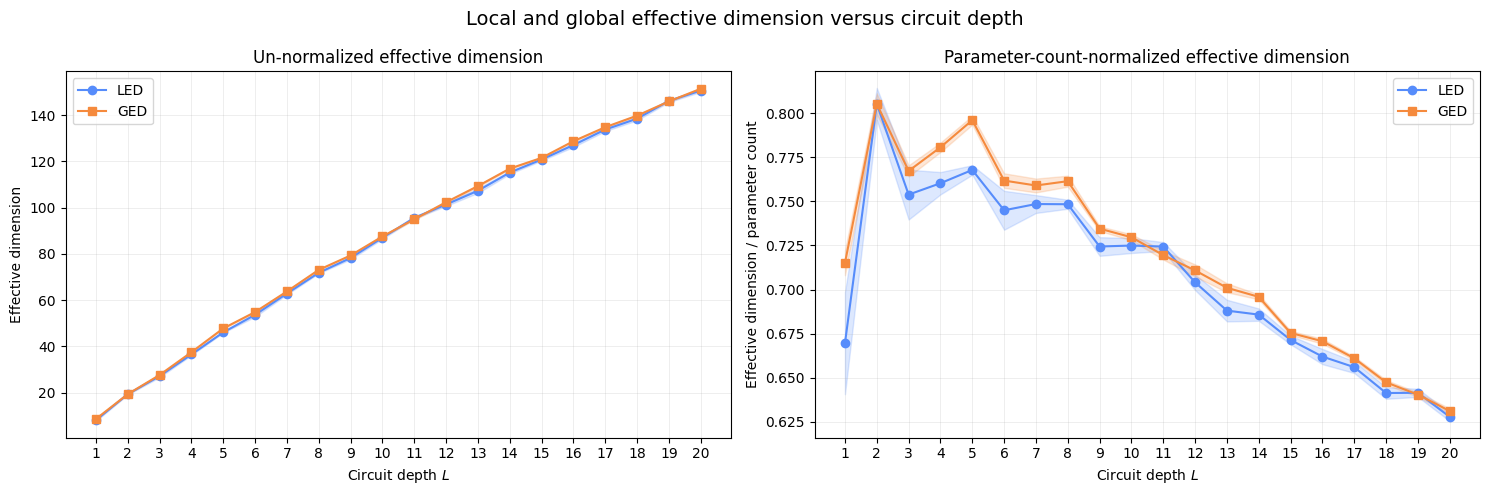

In [14]:
figure, axes = plot_effective_dimension_depth_sweep(
    led_result=led_result,
    ged_result=ged_result,
    model_factory=model_factory,
    output_path="results/effective_dimension_depth_sweep.png",
)

plt.show()

In [ ]:
print_effective_dimension_depth_sweep(
    led_result=led_result,
    ged_result=ged_result,
    model_factory=model_factory,
)